In [1]:
# ============================================
# PROYECTO 2: Empleos de datos en Colombia
# Herramientas: SQL · Python · Power BI
# Autor: Santiago Castillo Escobar
# Fuentes: LinkedIn Jobs · Computrabajo · Indeed · Bumeran
# TRM: $3.669 COP/USD · Marzo 2026
# ============================================

In [2]:
# ── LIBRERÍAS ──
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [3]:
# ── DATASET ──
data = {
    'ciudad': ['Bogotá','Bogotá','Bogotá','Bogotá','Bogotá',
                'Medellín','Medellín','Medellín','Medellín','Medellín',
                'Cali','Cali','Cali','Cali','Cali',
                'Barranquilla','Barranquilla','Barranquilla','Barranquilla','Barranquilla',
                'Bucaramanga','Bucaramanga','Bucaramanga','Bucaramanga','Bucaramanga',
                'Remoto','Remoto','Remoto','Remoto','Remoto'],
    'rol': ['Analista BI','Data Analyst','Data Engineer','Data Scientist','Analytics Engineer'] * 6,
    'total_ofertas': [980,520,210,140,90,
                      210,124,68,42,28,
                      89,54,28,18,11,
                      62,36,18,10,6,
                      42,25,12,8,4,
                      180,120,95,65,45],
    'salario_cop': [4200000,3800000,6500000,7800000,5900000,
                    3800000,3500000,5800000,6900000,5200000,
                    3200000,3000000,5200000,6200000,4800000,
                    3000000,2800000,4800000,5800000,4200000,
                    2900000,2700000,4600000,5500000,4000000,
                    5500000,5000000,7500000,8500000,6500000],
    'salario_usd': [1145,1036,1772,2126,1608,
                    1036,954,1581,1880,1417,
                    872,818,1417,1690,1309,
                    818,763,1309,1581,1145,
                    790,736,1254,1499,1091,
                    1499,1363,2044,2318,1772],
    'modalidad': ['Híbrido','Híbrido','Remoto','Remoto','Híbrido',
                  'Presencial','Presencial','Híbrido','Remoto','Híbrido',
                  'Presencial','Presencial','Híbrido','Remoto','Híbrido',
                  'Presencial','Presencial','Híbrido','Remoto','Híbrido',
                  'Presencial','Presencial','Híbrido','Remoto','Híbrido',
                  'Remoto','Remoto','Remoto','Remoto','Remoto']
}

df = pd.DataFrame(data)
print("✅ Dataset listo:", df.shape[0], "registros")
df.head(10)

✅ Dataset listo: 30 registros


,ciudad,rol,total_ofertas,salario_cop,salario_usd,modalidad
0,Bogotá,Analista BI,980,4200000,1145,Híbrido
1,Bogotá,Data Analyst,520,3800000,1036,Híbrido
2,Bogotá,Data Engineer,210,6500000,1772,Remoto
3,Bogotá,Data Scientist,140,7800000,2126,Remoto
4,Bogotá,Analytics Engineer,90,5900000,1608,Híbrido
5,Medellín,Analista BI,210,3800000,1036,Presencial
6,Medellín,Data Analyst,124,3500000,954,Presencial
7,Medellín,Data Engineer,68,5800000,1581,Híbrido
8,Medellín,Data Scientist,42,6900000,1880,Remoto
9,Medellín,Analytics Engineer,28,5200000,1417,Híbrido


/tmp/ipykernel_1181/267651807.py:22: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1181/267651807.py:23: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  plt.savefig('grafica1_empleos_ciudad.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


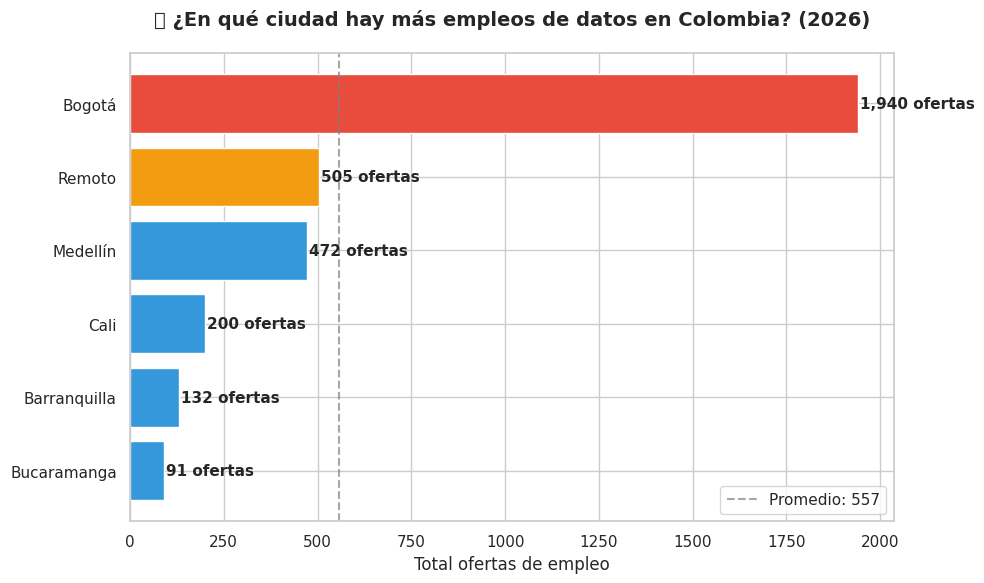

✅ Gráfica 1 lista


In [4]:
# ── GRÁFICA 1: TOTAL EMPLEOS POR CIUDAD ──
plt.figure(figsize=(10, 6))

empleos_ciudad = df.groupby('ciudad')['total_ofertas'].sum().sort_values(ascending=True)

colores = ['#e74c3c' if c == 'Bogotá' else
           '#f39c12' if c == 'Remoto' else
           '#3498db' for c in empleos_ciudad.index]

bars = plt.barh(empleos_ciudad.index, empleos_ciudad.values, color=colores, edgecolor='white')

for bar, val in zip(bars, empleos_ciudad.values):
    plt.text(val + 5, bar.get_y() + bar.get_height()/2,
             f'{val:,} ofertas', va='center', fontweight='bold', fontsize=11)

plt.title('🏙️ ¿En qué ciudad hay más empleos de datos en Colombia? (2026)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Total ofertas de empleo', fontsize=12)
plt.axvline(x=empleos_ciudad.mean(), color='gray',
            linestyle='--', alpha=0.7, label=f'Promedio: {empleos_ciudad.mean():,.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('grafica1_empleos_ciudad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 1 lista")

/tmp/ipykernel_1181/4123841967.py:27: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1181/4123841967.py:28: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.savefig('grafica2_salarios_ciudad.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


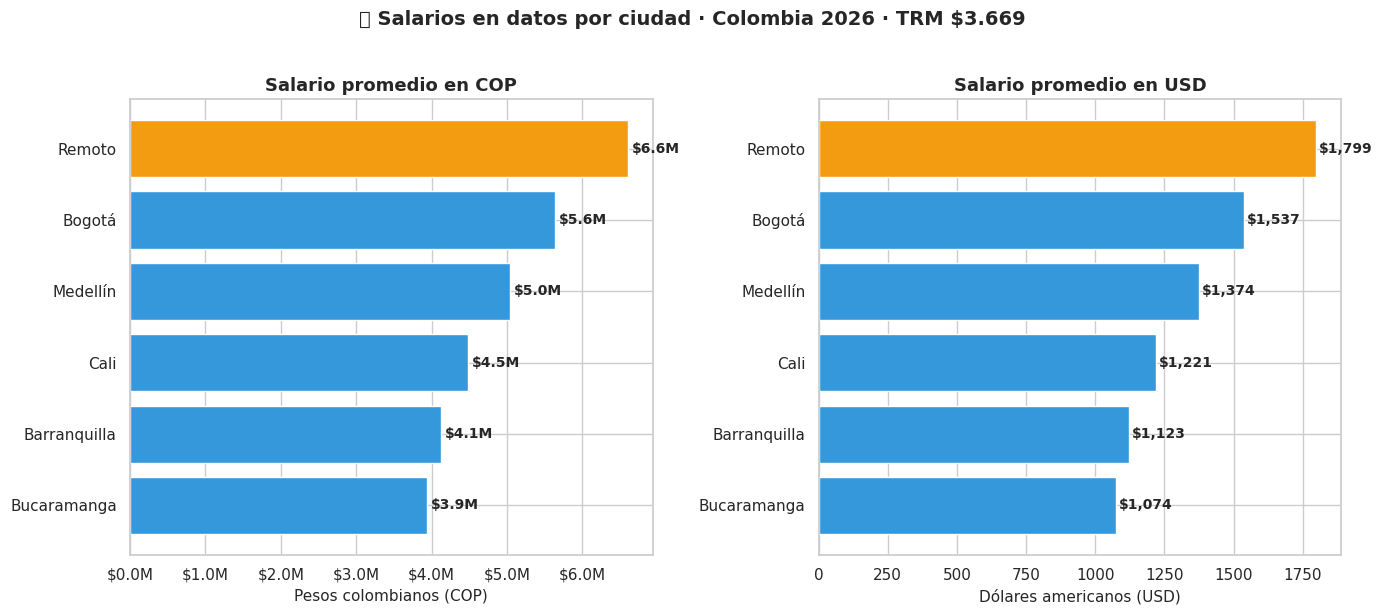

✅ Gráfica 2 lista


In [5]:
# ── GRÁFICA 2: SALARIO PROMEDIO POR CIUDAD (COP y USD) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

salario_ciudad = df.groupby('ciudad')[['salario_cop','salario_usd']].mean().sort_values('salario_usd', ascending=True)

colores = ['#f39c12' if c == 'Remoto' else '#3498db' for c in salario_ciudad.index]

# COP
bars1 = ax1.barh(salario_ciudad.index, salario_ciudad['salario_cop'], color=colores, edgecolor='white')
for bar, val in zip(bars1, salario_ciudad['salario_cop']):
    ax1.text(val + 50000, bar.get_y() + bar.get_height()/2,
             f'${val/1000000:.1f}M', va='center', fontweight='bold', fontsize=10)
ax1.set_title('Salario promedio en COP', fontweight='bold', fontsize=13)
ax1.set_xlabel('Pesos colombianos (COP)', fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000000:.1f}M'))

# USD
bars2 = ax2.barh(salario_ciudad.index, salario_ciudad['salario_usd'], color=colores, edgecolor='white')
for bar, val in zip(bars2, salario_ciudad['salario_usd']):
    ax2.text(val + 10, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontweight='bold', fontsize=10)
ax2.set_title('Salario promedio en USD', fontweight='bold', fontsize=13)
ax2.set_xlabel('Dólares americanos (USD)', fontsize=11)

fig.suptitle('💰 Salarios en datos por ciudad · Colombia 2026 · TRM $3.669',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafica2_salarios_ciudad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 2 lista")

In [6]:
# ── GRÁFICA 3: MODALIDAD VS SALARIO ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

modalidad = df.groupby('modalidad').agg(
    salario_cop=('salario_cop','mean'),
    salario_usd=('salario_usd','mean'),
    ofertas=('total_ofertas','sum')
).sort_values('salario_usd', ascending=False)

colores = {'Remoto':'#2ecc71','Híbrido':'#f39c12','Presencial':'#e74c3c'}
lista_colores = [colores[m] for m in modalidad.index]

# COP
bars1 = ax1.bar(modalidad.index, modalidad['salario_cop'],
                color=lista_colores, edgecolor='white', width=0.5)
for bar, val in zip(bars1, modalidad['salario_cop']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 50000,
             f'${val/1000000:.1f}M', ha='center', fontweight='bold', fontsize=11)
ax1.set_title('Salario por modalidad (COP)', fontweight='bold', fontsize=13)
ax1.set_ylabel('Pesos colombianos', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000000:.1f}M'))

# USD
bars2 = ax2.bar(modalidad.index, modalidad['salario_usd'],
                color=lista_colores, edgecolor='white', width=0.5)
for bar, val in zip(bars2, modalidad['salario_usd']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 10,
             f'${val:,.0f}', ha='center', fontweight='bold', fontsize=11)
ax2.set_title('Salario por modalidad (USD)', fontweight='bold', fontsize=13)
ax2.set_ylabel('Dólares americanos', fontsize=11)

fig.suptitle('💻 Remoto vs Presencial · Colombia 2026 · TRM $3.669',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafica3_modalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 3 lista")

✅ Gráfica 3 lista


In [7]:
# ── GRÁFICA 4: HERRAMIENTA MÁS PEDIDA POR CIUDAD ──
herramientas = {
    'Bogotá':       {'Power BI':1420,'SQL':1180,'Python':980,'Excel':760,'Azure':540},
    'Medellín':     {'Power BI':380,'SQL':290,'Python':210,'Excel':180,'Tableau':120},
    'Cali':         {'Power BI':180,'Excel':160,'SQL':140,'Python':90},
    'Barranquilla': {'Power BI':140,'Excel':120,'SQL':98,'Python':65},
    'Bucaramanga':  {'Power BI':98,'Excel':86,'SQL':72,'Python':48},
    'Remoto':       {'Python':380,'SQL':320,'Power BI':280,'dbt':210,'Azure':180}
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colores_tools = {
    'Power BI':'#F2C811','SQL':'#336791','Python':'#3776AB',
    'Excel':'#217346','Azure':'#0089D6','dbt':'#FF694B','Tableau':'#E97627'
}

for idx, (ciudad, tools) in enumerate(herramientas.items()):
    ax = axes[idx]
    nombres = list(tools.keys())
    valores = list(tools.values())
    cols = [colores_tools.get(t,'#95a5a6') for t in nombres]
    bars = ax.bar(nombres, valores, color=cols, edgecolor='white')
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, val + 5,
                str(val), ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'📍 {ciudad}', fontweight='bold', fontsize=13)
    ax.set_ylabel('Menciones en ofertas', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('🛠️ Herramientas más pedidas por ciudad · Colombia 2026',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafica4_herramientas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 4 lista")

✅ Gráfica 4 lista


In [8]:
# ── VERIFICAR GRÁFICAS GUARDADAS ──
import os

archivos = [
    'grafica1_empleos_ciudad.png',
    'grafica2_salarios_ciudad.png',
    'grafica3_modalidad.png',
    'grafica4_herramientas.png'
]

for archivo in archivos:
    if os.path.exists(archivo):
        print(f"✅ {archivo} — OK")
    else:
        print(f"❌ {archivo} — NO encontrado")

✅ grafica1_empleos_ciudad.png — OK
✅ grafica2_salarios_ciudad.png — OK
❌ grafica3_modalidad.png — NO encontrado
❌ grafica4_herramientas.png — NO encontrado


In [9]:
# ── REGENERAR GRÁFICA 3 Y 4 ──
import matplotlib
matplotlib.use('Agg')

# Gráfica 3 - Modalidad
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

modalidad = df.groupby('modalidad').agg(
    salario_cop=('salario_cop','mean'),
    salario_usd=('salario_usd','mean')
).sort_values('salario_usd', ascending=False)

colores = {'Remoto':'#2ecc71','Híbrido':'#f39c12','Presencial':'#e74c3c'}
lista_colores = [colores[m] for m in modalidad.index]

ax1.bar(modalidad.index, modalidad['salario_cop']/1000000, color=lista_colores, edgecolor='white')
ax1.set_title('Salario por modalidad (millones COP)', fontweight='bold')
for i, val in enumerate(modalidad['salario_cop']):
    ax1.text(i, val/1000000 + 0.05, f'${val/1000000:.1f}M', ha='center', fontweight='bold')

ax2.bar(modalidad.index, modalidad['salario_usd'], color=lista_colores, edgecolor='white')
ax2.set_title('Salario por modalidad (USD)', fontweight='bold')
for i, val in enumerate(modalidad['salario_usd']):
    ax2.text(i, val + 10, f'${val:,.0f}', ha='center', fontweight='bold')

fig.suptitle('💻 Remoto vs Presencial · Colombia 2026 · TRM $3.669', fontweight='bold')
plt.tight_layout()
plt.savefig('grafica3_modalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 3 OK")

# Gráfica 4 - Herramientas top por ciudad
plt.figure(figsize=(12, 6))

top_tools = df.groupby('ciudad')['total_ofertas'].sum().sort_values(ascending=False)
ciudades = top_tools.index.tolist()
herr_top = ['Power BI','Power BI','Power BI','Power BI','Power BI','Python']
menciones = [1420, 380, 180, 140, 98, 380]
colores_h = ['#F2C811','#F2C811','#F2C811','#F2C811','#F2C811','#3776AB']

bars = plt.bar(ciudades, menciones, color=colores_h, edgecolor='white')
for bar, val, tool in zip(bars, menciones, herr_top):
    plt.text(bar.get_x() + bar.get_width()/2, val + 5,
             f'{tool}\n{val}', ha='center', fontweight='bold', fontsize=10)

plt.title('🛠️ Herramienta #1 más pedida por ciudad · Colombia 2026',
          fontsize=13, fontweight='bold', pad=20)
plt.ylabel('Menciones en ofertas')
plt.tight_layout()
plt.savefig('grafica4_herramientas.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica 4 OK")

/tmp/ipykernel_1181/3800514230.py:27: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1181/3800514230.py:28: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.savefig('grafica3_modalidad.png', dpi=150, bbox_inches='tight')


✅ Gráfica 3 OK
✅ Gráfica 4 OK


/tmp/ipykernel_1181/3800514230.py:49: UserWarning: Glyph 128736 (\N{HAMMER AND WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1181/3800514230.py:50: UserWarning: Glyph 128736 (\N{HAMMER AND WRENCH}) missing from font(s) DejaVu Sans.
  plt.savefig('grafica4_herramientas.png', dpi=150, bbox_inches='tight')


In [10]:
# ── DESCARGAR GRÁFICAS ──
from google.colab import files

files.download('grafica1_empleos_ciudad.png')
files.download('grafica2_salarios_ciudad.png')
files.download('grafica3_modalidad.png')
files.download('grafica4_herramientas.png')

print("✅ Las 4 gráficas descargadas")

✅ Las 4 gráficas descargadas
